In [19]:
# úkol 1
import scipy.sparse as sparse
import numpy as np

def A_assembly(n=3, epsilon=1e-1):
    A = sparse.lil_matrix((n*n, n*n))
    sousedi = 0
    for i in range(n*n):
        
            if i+1 < n*n and i+1%n != 0:
                A[i, i+1] = epsilon
                sousedi = sousedi + 1
            if i-1 >=0 and i%n!=0:
                A[i, i-1] = epsilon
                sousedi = sousedi + 1
            if i-n >=0:
                A[i, i-n] = epsilon
                sousedi = sousedi + 1
            if i+n< n*n:
                A[i, i+n] = epsilon
                sousedi = sousedi +1
            A[i,i] = 1 + sousedi*epsilon
            sousedi = 0
    return A

A = A_assembly(3, 1e-1)
B = A_assembly(100, 2e-1)
print(A.todense())
print(B.todense())


[[1.2 0.1 0.  0.1 0.  0.  0.  0.  0. ]
 [0.1 1.3 0.1 0.  0.1 0.  0.  0.  0. ]
 [0.  0.1 1.3 0.1 0.  0.1 0.  0.  0. ]
 [0.1 0.  0.  1.3 0.1 0.  0.1 0.  0. ]
 [0.  0.1 0.  0.1 1.4 0.1 0.  0.1 0. ]
 [0.  0.  0.1 0.  0.1 1.4 0.1 0.  0.1]
 [0.  0.  0.  0.1 0.  0.  1.2 0.1 0. ]
 [0.  0.  0.  0.  0.1 0.  0.1 1.3 0.1]
 [0.  0.  0.  0.  0.  0.1 0.  0.1 1.2]]
[[1.4 0.2 0.  ... 0.  0.  0. ]
 [0.2 1.6 0.2 ... 0.  0.  0. ]
 [0.  0.2 1.6 ... 0.  0.  0. ]
 ...
 [0.  0.  0.  ... 1.6 0.2 0. ]
 [0.  0.  0.  ... 0.2 1.6 0.2]
 [0.  0.  0.  ... 0.  0.2 1.4]]


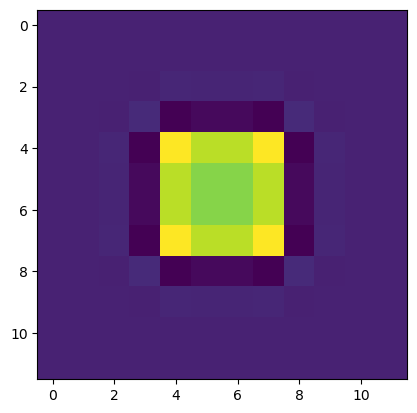

In [31]:
# úkol 2
import matplotlib.pyplot as plt
import scipy as sp
from scipy.sparse import csr_matrix, csc_matrix, coo_matrix, lil_matrix
import scipy.sparse as sparse
import scipy.sparse.linalg as sla
n = 12
epsilon = 2e-1
A = A_assembly(n, epsilon)
A= A.tocsr()
b = np.zeros((n, n))
b[n//2 - n//6:n//2 + n//6,n//2 - n//6:n//2 + n//6] = 1
b = b.flatten()
x = sla.spsolve(A, b)

plt.imshow(b.reshape((n, n)))
plt.imshow(x.reshape((n,n)))

